# Confident and wrong

This notebook goes with the post of the same name. It lets you run the experiment yourself.

**The question.** A decision model picks one option from a list and reports how sure it is. When can you trust that
number? Does it depend on how the model was trained?

**The test.** A toy security world produces sessions of log events. Each session comes from one of 12 classes, such
as `brute_force` or `benign`. The world is built so that the true probability of each class is known exactly. A small
model is trained in three ways, and its reported confidence is compared with the truth.

**What you can do here.**

1. Look at one session and its exact probabilities.
2. Train the model in the three ways in a short run (about 1 minute on a laptop).
3. Load the results of the full run (about 45 minutes) and draw the two main charts.

The code is in `alert_triage.py`. This notebook only calls it.

In [1]:
# Run this cell first. On Colab it gets the repository. On your own machine it does nothing.
import os, sys
if "google.colab" in sys.modules and not os.path.exists("alert_triage.py"):
    !git clone -q https://github.com/vlrmzz/ai-claims-experiments
    %cd ai-claims-experiments/confident-and-wrong

In [2]:
import json, time

import numpy as np
import torch
import matplotlib.pyplot as plt

import alert_triage as at

print(len(at.CLASSES), "classes:", ", ".join(at.CLASSES))

12 classes: benign, brute_force, credential_stuffing, port_scan, sql_injection, web_fuzzing, data_exfiltration, lateral_movement, privilege_escalation, c2_beaconing, phishing, ransomware


## 1. One session and its exact probabilities

Most events in a session are ordinary traffic. A class adds a few events of its own. Because the rules of the world
are known, the correct probability of each option can be calculated. No model can do better than these numbers.

In [3]:
events = ["login_fail", "login_ok", "http_200", "login_fail", "dns_query"]
options = ["brute_force", "credential_stuffing", "phishing", "benign"]

ev = np.zeros((1, at.L_MAX), dtype=int)
ev[0, :len(events)] = [at.EVENTS.index(e) for e in events]
opts = np.array([[at.CLASSES.index(c) for c in options]])
p = at.true_posterior(opts, ev, np.array([len(events)]))[0]

print("session:", ", ".join(events), "\n")
for o, x in zip(options, p):
    print(f"  {o:22s} {x:6.1%}  {'#' * int(round(x * 40))}")

session: login_fail, login_ok, http_200, login_fail, dns_query 

  brute_force             63.3%  #########################
  credential_stuffing     34.4%  ##############
  phishing                 0.5%  
  benign                   1.8%  #


## 2. Three ways to train, five conditions to test

The three ways to train:

- `ce`: cross-entropy, the usual method.
- `acc`: a reward of 1 for the right answer.
- `rlcd`: a reward from a proper scoring rule, which pays the model for honest probabilities.

Each trained model is tested as it was trained (4 options) and under four changes: 8 options, 12 options, a log
format it cannot read, and traffic that is 90 % benign.

The table shows accuracy, mean confidence, and the difference between them. A model with honest confidence has a
difference near 0. A positive difference means the model is more sure than it should be.

In [4]:
N_TRAIN, STEPS, N_TEST = 4000, 400, 1000        # the full run: up to 64,000 sessions, 3,000 steps, 5,000 tests

def table(results):
    arms = list(results)
    print(f"{'condition':26s}" + "".join(f"{a:^24s}" for a in arms))
    print(f"{'':26s}" + "  acc   conf   diff     " * len(arms))
    for cond, info in at.CONDITIONS.items():
        row = f"{info['label']:26s}"
        for a in arms:
            m = results[a][cond]["model"]
            row += f" {m['accuracy']:5.2f}  {m['confidence']:5.2f}  {m['confidence'] - m['accuracy']:+5.2f}     "
        print(row)

quick = {}
for arm in at.ARMS:
    t0 = time.time()
    model = at.train(arm, seed=0, n_train=N_TRAIN, steps=STEPS)
    quick[arm] = at.evaluate(model, seed=0, n_test=N_TEST)
    print(f"trained {arm:5s} in {time.time() - t0:.0f} s")
print()
table(quick)

trained ce    in 14 s


trained acc   in 13 s


trained rlcd  in 13 s

condition                            ce                     acc                     rlcd          
                            acc   conf   diff       acc   conf   diff       acc   conf   diff     
as trained: 4 options       0.84   0.85  +0.01       0.85   0.97  +0.13       0.83   0.86  +0.02     
8 options                   0.77   0.76  -0.01       0.76   0.96  +0.21       0.76   0.77  +0.01     
12 options                  0.72   0.69  -0.03       0.71   0.96  +0.25       0.72   0.71  -0.01     
unreadable log format       0.24   0.51  +0.27       0.27   0.71  +0.44       0.25   0.51  +0.26     
90 % benign traffic         0.84   0.69  -0.16       0.83   0.97  +0.13       0.84   0.70  -0.13     


## 3. The full run

`results.json` holds the full experiment: 3 methods, 4 training-set sizes, 3 seeds.

The first chart shows calibration error against the amount of training data, tested as trained. Calibration error
is the average distance between confidence and accuracy, so lower is better. The grey line is the error of the
exact probabilities on the same test set: the best possible.

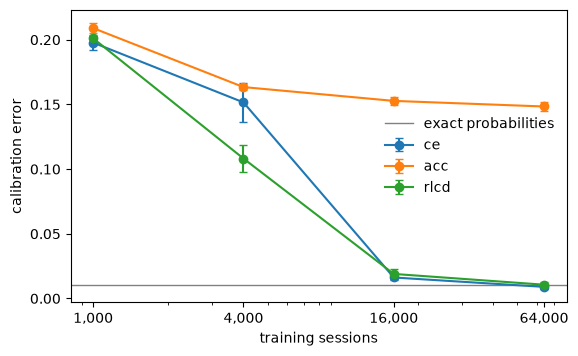

 training sessions        ce       acc      rlcd
             1,000     0.198     0.209     0.201
             4,000     0.152     0.163     0.108
            16,000     0.016     0.153     0.019
            64,000     0.009     0.148     0.011


In [5]:
r = json.load(open("results.json"))
sizes, seeds = r["config"]["train_sizes"], r["config"]["seeds"]

def stat(arm, n, cond, key, which="model"):
    v = [r["runs"][f"{arm}/{n}/{s}"][cond][which][key] for s in seeds]
    return float(np.mean(v)), float(np.std(v))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for arm in at.ARMS:
    m, sd = zip(*[stat(arm, n, "trained", "ece") for n in sizes])
    ax.errorbar(sizes, m, yerr=sd, marker="o", capsize=3, label=arm)
ax.axhline(stat("ce", sizes[-1], "trained", "ece", "truth")[0], color="grey", lw=1, label="exact probabilities")
ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlabel("training sessions"); ax.set_ylabel("calibration error"); ax.legend(frameon=False)
plt.show()

print(f"{'training sessions':>18s}" + "".join(f"{a:>10s}" for a in at.ARMS))
for n in sizes:
    print(f"{n:>18,}" + "".join(f"{stat(a, n, 'trained', 'ece')[0]:>10.3f}" for a in at.ARMS))

The second chart uses the models trained on the most data. For each condition it shows accuracy (bar) and mean
confidence (black line). Where the line is far above the bar, the model is confident and wrong.

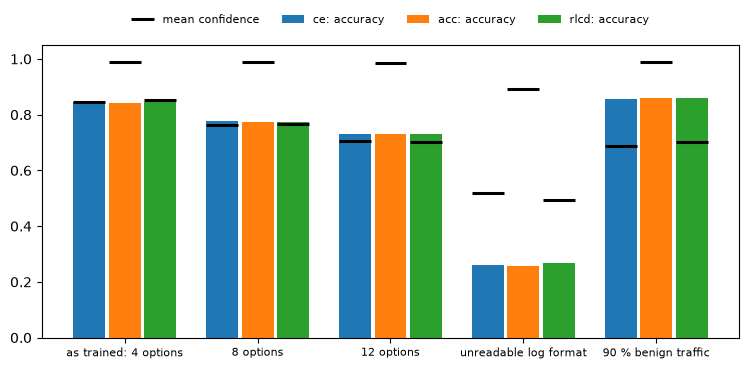

trained on 64,000 sessions

condition                            ce                     acc                     rlcd          
                            acc   conf   diff       acc   conf   diff       acc   conf   diff     
as trained: 4 options       0.84   0.85  +0.00       0.84   0.99  +0.15       0.84   0.85  +0.01     
8 options                   0.78   0.76  -0.01       0.77   0.99  +0.22       0.78   0.77  -0.01     
12 options                  0.73   0.70  -0.03       0.73   0.98  +0.25       0.73   0.70  -0.03     
unreadable log format       0.26   0.52  +0.26       0.26   0.89  +0.63       0.27   0.49  +0.23     
90 % benign traffic         0.86   0.69  -0.17       0.86   0.99  +0.13       0.86   0.70  -0.16     


In [6]:
n = sizes[-1]
conds = list(at.CONDITIONS)
arms = list(at.ARMS)
x = np.arange(len(conds))
width = 0.8 / len(arms)

fig, ax = plt.subplots(figsize=(9, 3.8))
for i, arm in enumerate(arms):
    acc = [stat(arm, n, c, "accuracy")[0] for c in conds]
    conf = [stat(arm, n, c, "confidence")[0] for c in conds]
    pos = x + (i - (len(arms) - 1) / 2) * width
    ax.bar(pos, acc, width * 0.9, color=f"C{i}", label=f"{arm}: accuracy")
    ax.hlines(conf, pos - width * 0.45, pos + width * 0.45, color="black", linewidth=2.2,
              label="mean confidence" if i == 0 else None)
ax.set_xticks(x); ax.set_xticklabels([at.CONDITIONS[c]["label"] for c in conds], fontsize=8)
ax.set_ylim(0, 1.05); ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.14))
plt.show()

print(f"trained on {n:,} sessions\n")
table({a: {c: {"model": {"accuracy": stat(a, n, c, "accuracy")[0], "confidence": stat(a, n, c, "confidence")[0]}}
           for c in conds} for a in arms})

## 4. Change something

- `N_TRAIN` and `STEPS` in section 2. In the full run, `ce` and `rlcd` needed about 16,000 sessions before their
  confidence was honest. `acc` did not get there with any amount.
- `at.SIGNAL`: the share of a session's events that come from its class. A lower value makes the world more
  ambiguous. It is read when the file is imported, so change it in `alert_triage.py` and restart.
- The session in section 1: put in your own events and options.

To repeat the full run from a terminal (about 45 minutes on a laptop), and to make the figures of the post:

```
python alert_triage.py run
python make_figs.py
```

The two files in `data/` are copied unchanged from the [Laya](https://github.com/NandhaKishorM/laya) repository
(Apache 2.0). `make_figs.py` uses them for the two figures that show the same pattern in a real model.